# Grocery Receipt Lifestyle Clustering 

## 1) IMPORTS

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import umap, hdbscan, lightgbm as lgb

✅ All imports done


### 2) Loading of data

In [3]:
orders     = pd.read_csv("orders.csv")
op_prior   = pd.read_csv("order_products__prior.csv")
op_train   = pd.read_csv("order_products__train.csv")
products   = pd.read_csv("products.csv")
aisles     = pd.read_csv("aisles.csv")
depts      = pd.read_csv("departments.csv")
 
for name, df in [("orders",orders),("op_prior",op_prior),("op_train",op_train),
                 ("products",products),("aisles",aisles),("depts",depts)]:
    print(f"  {name}: {df.shape}")

  orders: (3421083, 7)
  op_prior: (32434489, 4)
  op_train: (1384617, 4)
  products: (49688, 4)
  aisles: (134, 2)
  depts: (21, 2)


### 3) Merge

In [4]:
products = products.merge(aisles, on="aisle_id").merge(depts, on="department_id")
all_op   = pd.concat([op_prior, op_train], ignore_index=True)
df       = all_op.merge(products, on="product_id").merge(orders, on="order_id")
print(f"\nMerged table: {df.shape}")


Merged table: (33819106, 15)


In [ ]:
df.head()

### 4) Cleaning 

In [5]:
df["days_since_prior_order"] = df["days_since_prior_order"].fillna(0)
 
# Keep users with 5+ orders only
good_users = orders.groupby("user_id")["order_id"].nunique()
good_users = good_users[good_users >= 5].index
df = df[df["user_id"].isin(good_users)]
print(f"Users after filter: {df['user_id'].nunique():,}")

Users after filter: 182,223


### 5) Eda

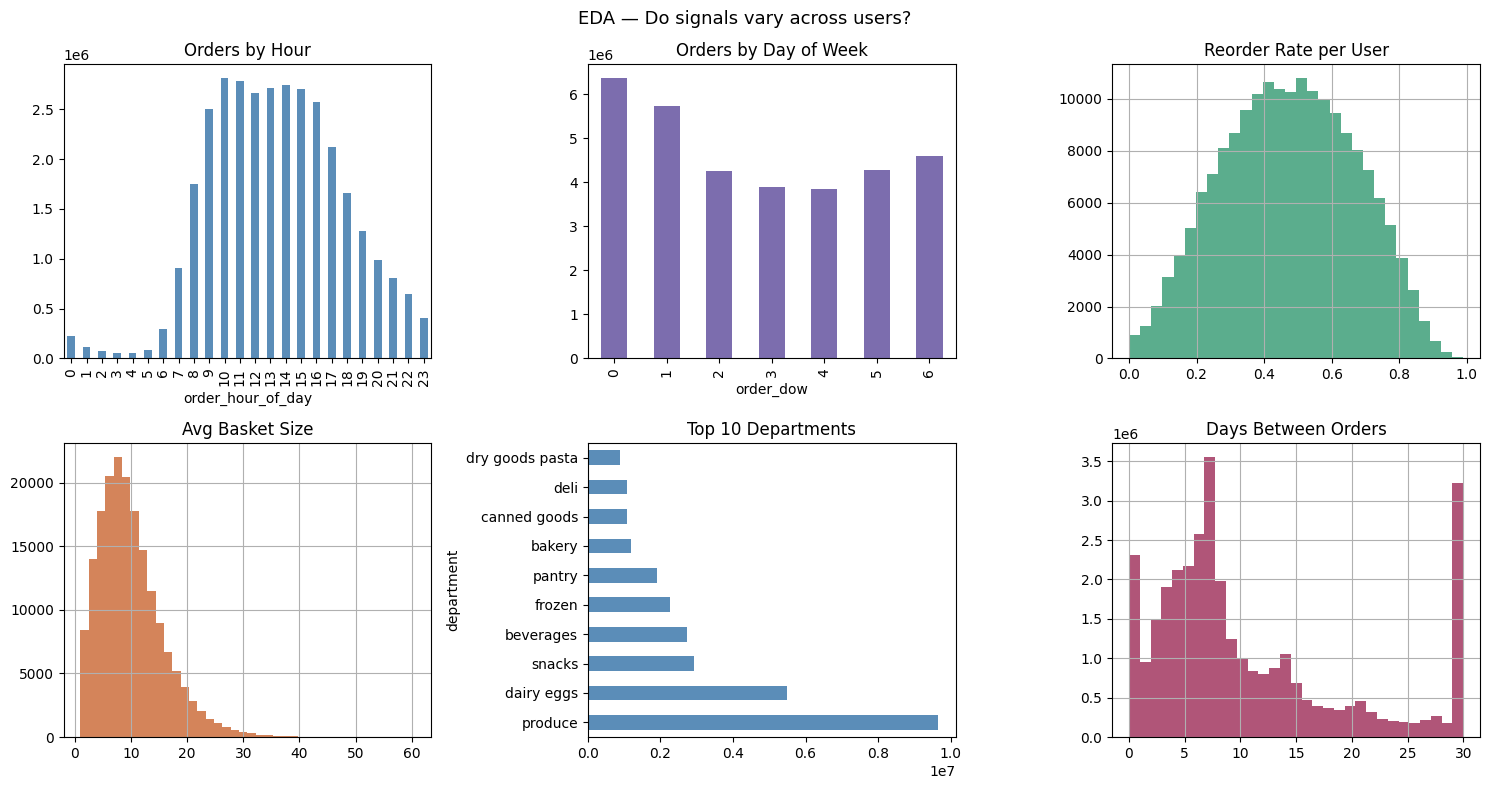

Saved: eda.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("EDA — Do signals vary across users?", fontsize=13)
 
df["order_hour_of_day"].value_counts().sort_index().plot(kind="bar", ax=axes[0,0], color="#5B8DB8", title="Orders by Hour")
df["order_dow"].value_counts().sort_index().plot(kind="bar", ax=axes[0,1], color="#7C6DAE", title="Orders by Day of Week")
df.groupby("user_id")["reordered"].mean().hist(bins=30, ax=axes[0,2], color="#5BAD8D"); axes[0,2].set_title("Reorder Rate per User")
df.groupby(["user_id","order_id"]).size().groupby("user_id").mean().hist(bins=40, ax=axes[1,0], color="#D4845A"); axes[1,0].set_title("Avg Basket Size")
df["department"].value_counts().head(10).plot(kind="barh", ax=axes[1,1], color="#5B8DB8", title="Top 10 Departments")
df["days_since_prior_order"].hist(bins=31, ax=axes[1,2], color="#B05578"); axes[1,2].set_title("Days Between Orders")
 
plt.tight_layout(); plt.savefig("eda.png", dpi=130); plt.show()
print("Saved: eda.png")

### 6) FEATURE ENGINEERING (16 features per user)

In [7]:
uid = "user_id"
 
# Timing
timing = orders[orders[uid].isin(good_users)].groupby(uid).agg(
    total_orders     = ("order_id",               "count"),
    avg_hour         = ("order_hour_of_day",       "mean"),
    std_hour         = ("order_hour_of_day",        "std"),
    avg_dow          = ("order_dow",               "mean"),
    avg_days_between = ("days_since_prior_order",  "mean"),
    std_days_between = ("days_since_prior_order",   "std"),
).fillna(0).reset_index()
 
# Basket size
basket = df.groupby([uid,"order_id"]).size().reset_index(name="n")
basket = basket.groupby(uid)["n"].agg(avg_basket="mean", std_basket="std", max_basket="max").fillna(0).reset_index()
 
# Reorder rate
reorder = df.groupby(uid)["reordered"].mean().reset_index(name="reorder_rate")
 
# Department diversity (entropy)
diversity = df.groupby(uid)["department"].apply(
    lambda x: entropy(x.value_counts(normalize=True))
).reset_index(name="dept_entropy")
 
# Health proxy (% of orders from healthy depts)
healthy = {"produce","dairy eggs","beverages","bakery","breakfast","canned goods"}
df["is_healthy"] = df["department"].isin(healthy).astype(int)
health = df.groupby(uid)["is_healthy"].mean().reset_index(name="health_proxy")
 
# Category drift (is user exploring more depts over time?)
orders2 = orders[orders[uid].isin(good_users)].copy()
orders2["half"] = orders2.groupby(uid)["order_number"].transform(lambda x: (x > x.median()).astype(int))
df2 = df.merge(orders2[[uid,"order_id","half"]], on=[uid,"order_id"], how="left")
 
def drift(g):
    e0 = entropy(g[g["half"]==0]["department"].value_counts(normalize=True)) if (g["half"]==0).any() else 0
    e1 = entropy(g[g["half"]==1]["department"].value_counts(normalize=True)) if (g["half"]==1).any() else 0
    return e1 - e0
 
drift_feat = df2.groupby(uid).apply(drift).reset_index(name="category_drift")
 
# Combine all
feats = (timing
    .merge(basket,      on=uid)
    .merge(reorder,     on=uid)
    .merge(diversity,   on=uid)
    .merge(health,      on=uid)).fillna(0)

print(f"\nFeature table: {feats.shape}")
FCOLS = [c for c in feats.columns if c != uid]


Feature table: (182223, 13)


### 7) Scale

In [9]:
scaler  = StandardScaler()
X       = scaler.fit_transform(feats[FCOLS])
print(f"Scaled: {X.shape}")

Scaled: (182223, 12)


### 8) UMAP(16D -> 2D)


Running UMAP...


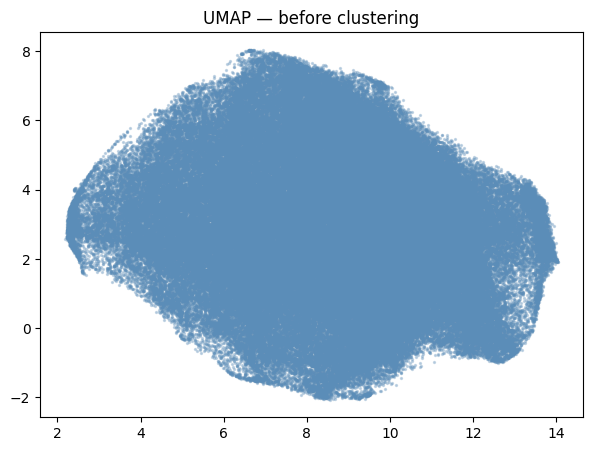

In [10]:
print("\nRunning UMAP...")
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X2d     = reducer.fit_transform(X)

plt.figure(figsize=(7,5))
plt.scatter(X2d[:,0], X2d[:,1], s=2, alpha=0.3, c="#5B8DB8")
plt.title("UMAP — before clustering"); plt.savefig("umap_raw.png", dpi=130); plt.show()

### 9) HDBSCAN

In [11]:
print("Running HDBSCAN...")
clust  = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=50)
labels = clust.fit_predict(X2d)
feats["cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Clusters: {n_clusters}  |  Noise: {(labels==-1).sum():,}")
print(pd.Series(labels).value_counts().sort_index())

Running HDBSCAN...
Clusters: 5  |  Noise: 29,396
-1     29396
 0      1739
 1       329
 2      2532
 3       570
 4    147657
Name: count, dtype: int64


### 10) Visualize

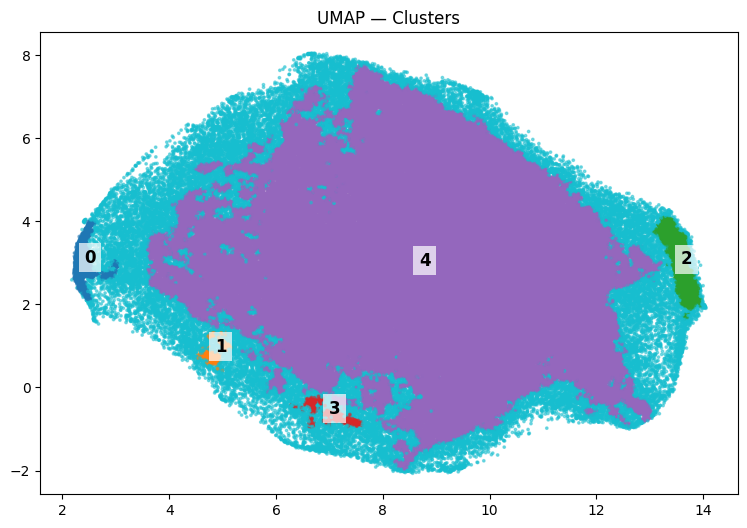

In [12]:
# Plot UMAP coloured by cluster
colors = plt.cm.tab10(np.array([l if l>=0 else 9 for l in labels]) / 10)
plt.figure(figsize=(9,6))
plt.scatter(X2d[:,0], X2d[:,1], c=colors, s=3, alpha=0.5)
for c in range(n_clusters):
    m = labels==c; cx,cy = X2d[m,0].mean(), X2d[m,1].mean()
    plt.text(cx, cy, str(c), fontsize=12, fontweight="bold",
             bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
plt.title("UMAP — Clusters"); plt.savefig("umap_clusters.png", dpi=130); plt.show()

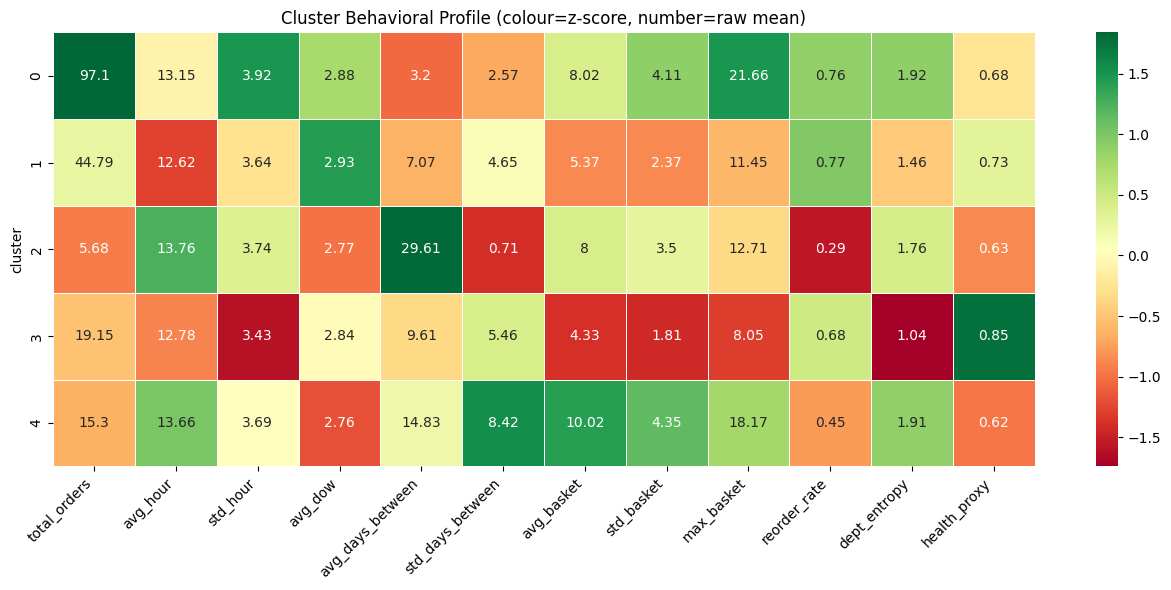


Raw cluster means:
cluster                0       1       2       3       4
total_orders      97.104  44.793   5.684  19.146  15.304
avg_hour          13.154  12.616  13.762  12.784  13.657
std_hour           3.918   3.640   3.741   3.429   3.691
avg_dow            2.885   2.929   2.770   2.837   2.758
avg_days_between   3.204   7.073  29.611   9.614  14.834
std_days_between   2.566   4.654   0.712   5.463   8.416
avg_basket         8.017   5.366   7.999   4.327  10.019
std_basket         4.107   2.367   3.501   1.812   4.353
max_basket        21.665  11.447  12.712   8.051  18.170
reorder_rate       0.758   0.772   0.295   0.683   0.446
dept_entropy       1.917   1.465   1.762   1.037   1.913
health_proxy       0.679   0.726   0.628   0.848   0.618


In [13]:
# Heatmap of cluster profiles
from scipy.stats import zscore
profile = feats[feats["cluster"]>=0].groupby("cluster")[FCOLS].mean()
profile_z = profile.apply(zscore, axis=0)
plt.figure(figsize=(13, max(4, n_clusters+1)))
sns.heatmap(profile_z, annot=profile.round(2), fmt="g", cmap="RdYlGn", linewidths=0.4)
plt.title("Cluster Behavioral Profile (colour=z-score, number=raw mean)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig("cluster_heatmap.png", dpi=130); plt.show()

print("\nRaw cluster means:")
print(profile.round(3).T)

In [14]:
NAMES = {
    0: "Power Shoppers",           # 97 orders, huge baskets, shops constantly
    1: "Weekly Routine Shoppers",  # moderate orders, ~7 day gap, consistent
    2: "Rare Explorers",           # only 5-6 orders, 30-day gap, low reorder
    3: "Creatures of Habit",       # same time/same dept every visit
    4: "Irregular Bulk Buyers",    # unpredictable schedule but big baskets
   -1: "Noise"
}
feats["cluster_name"] = feats["cluster"].map(NAMES).fillna("Unknown")
print("\nCluster counts:"); print(feats["cluster_name"].value_counts())


Cluster counts:
cluster_name
Irregular Bulk Buyers      147657
Noise                       29396
Rare Explorers               2532
Power Shoppers               1739
Creatures of Habit            570
Weekly Routine Shoppers       329
Name: count, dtype: int64


### 11) SILHOUETTE SCORE

In [15]:
valid = feats["cluster"] >= 0
score = silhouette_score(X[valid], feats.loc[valid,"cluster"],
                         sample_size=min(10_000, valid.sum()))
print(f"\nSilhouette Score: {score:.4f}  (>0.3 good, >0.5 great)")


Silhouette Score: 0.0815  (>0.3 good, >0.5 great)


### 12) SUPERVISED LAYER 1 — predict cluster from features


Training cluster classifier...
              precision    recall  f1-score   support

           0       0.58      0.52      0.55       348
           1       0.05      0.12      0.07        66
           2       0.87      0.92      0.89       506
           3       0.30      0.30      0.30       114
           4       0.99      0.99      0.99     29532

    accuracy                           0.98     30566
   macro avg       0.56      0.57      0.56     30566
weighted avg       0.98      0.98      0.98     30566



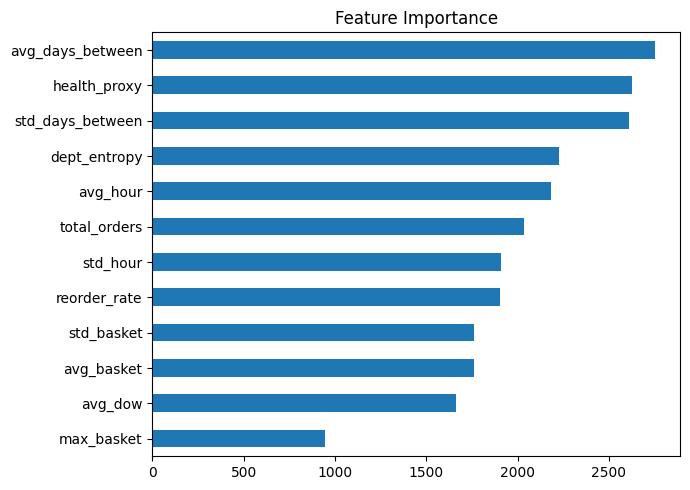

In [16]:
print("\nTraining cluster classifier...")
df_s = feats[feats["cluster"]>=0]
Xs, ys = df_s[FCOLS].values, df_s["cluster"].values
Xtr,Xte,ytr,yte = train_test_split(Xs, ys, test_size=0.2, random_state=42, stratify=ys)

m1 = lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
m1.fit(Xtr, ytr)
print(classification_report(yte, m1.predict(Xte), zero_division=0))

pd.Series(m1.feature_importances_, index=FCOLS).sort_values().plot(
    kind="barh", figsize=(7,5), title="Feature Importance")
plt.tight_layout(); plt.savefig("feat_importance.png", dpi=130); plt.show()

### 13) SUPERVISED LAYER 2 — predict next department

In [17]:
# --- SECTION 20-21 | SUPERVISED LAYER 2 — predict next department ---
print("\nPredicting next department per user...")

# Ground truth: top department in each user's last (train) order
last_dept = (op_train
    .merge(products[["product_id","department"]], on="product_id")
    .groupby("order_id")["department"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index(name="target_dept"))

train_orders = orders[orders["eval_set"]=="train"][["order_id","user_id"]]
targets = (train_orders
    .merge(last_dept, on="order_id")
    .merge(feats[[uid,"cluster"]][feats["cluster"]>=0], on=uid))

le = LabelEncoder()
targets["dept_code"] = le.fit_transform(targets["target_dept"])
X2, y2 = targets.merge(feats[[uid]+FCOLS], on=uid)[FCOLS].values, targets["dept_code"].values

Xtr2,Xte2,ytr2,yte2 = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)
m2 = lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1, class_weight="balanced")
m2.fit(Xtr2, ytr2)
print(classification_report(yte2, m2.predict(Xte2), target_names=le.classes_, zero_division=0))

# Which department does each lifestyle cluster buy from next?
targets["predicted_dept"] = le.inverse_transform(m2.predict(X2))
result = (targets.groupby("cluster")["predicted_dept"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index())
result["name"] = result["cluster"].map(NAMES)
print("\n📦 Most likely next dept per cluster:")
print(result[["name","predicted_dept"]].to_string(index=False))



Predicting next department per user...
                 precision    recall  f1-score   support

        alcohol       0.10      0.18      0.13       152
         babies       0.02      0.04      0.02       158
         bakery       0.03      0.07      0.04       248
      beverages       0.16      0.17      0.17      1787
      breakfast       0.01      0.02      0.02       151
           bulk       0.00      0.00      0.00         5
   canned goods       0.03      0.07      0.04       277
     dairy eggs       0.23      0.18      0.20      3155
           deli       0.04      0.06      0.05       253
dry goods pasta       0.02      0.03      0.02       188
         frozen       0.16      0.21      0.18      1157
      household       0.10      0.18      0.13       501
  international       0.00      0.00      0.00        49
   meat seafood       0.02      0.02      0.02       141
        missing       0.00      0.00      0.00        29
          other       0.00      0.00      0.00 